/home/minsungkim/.conda/envs/fact/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
INFO:fullprob_param_vs_pert_orig_nolog:Loading data & tokenizer...
INFO:fullprob_param_vs_pert_orig_nolog:Total entities: 50000
INFO:fullprob_param_vs_pert_orig_nolog:Using checkpoint: zipf_textlist_out_zipf_100_1_250816-151409 | gpt2_runs_0816/zipf_textlist_out_zipf_100_1_250816-151409/checkpoint-16000
Computing full probs: 100%|██████████| 50000/50000 [20:49<00:00, 40.03it/s]
INFO:fullprob_param_vs_pert_orig_nolog:Saved CSV: fullprob_PARAMvsPERTctxORIG_ALL_noLOG_step16000_zipf_textlist_out_zipf_100_1_250816-151409.csv
INFO:fullprob_param_vs_pert_orig_nolog:[birth_date] Pearson R (binned prob_param vs pert_ctx_orig exact match acc) = 0.6718 (bins=10)


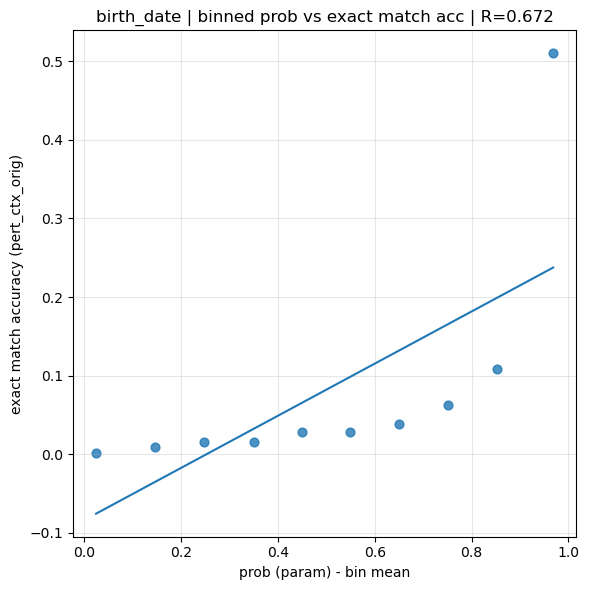

INFO:fullprob_param_vs_pert_orig_nolog:[university] Pearson R (binned prob_param vs pert_ctx_orig exact match acc) = 0.7897 (bins=10)


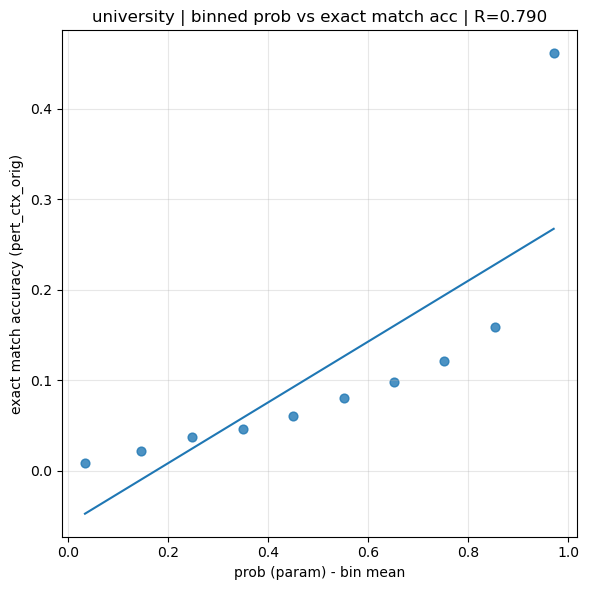

In [1]:
#!/usr/bin/env python3
# ==========================================
# Full cell: param vs pert_ctx_orig (full dataset, no log)
# - Use ALL entities (no rank sampling)
# - target probability = product of token probs (raw prob)
# - Final analysis:
#   * 10 bins based on prob_param
#   * Compute pert_ctx_orig exact match accuracy per bin
#   * Compute trend line + Pearson R from per-bin points
# ==========================================
import os, re, json, logging, gc, random
from pathlib import Path
from typing import List, Dict, Tuple, Optional

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from transformers import GPT2Tokenizer, GPT2LMHeadModel

# ---------- Logging/Seed ----------
logging.basicConfig(level=logging.INFO)
log = logging.getLogger("fullprob_param_vs_pert_orig_nolog")
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

# ---------- User settings ----------
MODEL_ROOT = Path("./gpt2_runs_0816")
RUN_DIR_NAME_FILTER: Optional[str] = "100_1"
CKPT_STEP_FIXED = 16000

TRAIN_JSON = "../dataset_generation/bioS_train_250806.json"
TRAIN_PERT_JSON = "../dataset_generation/bioS_train_250806_pert.json"

ATTR_KEYS  = ["birth_date", "university"]

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# ---------- Common utilities ----------
def load_json(path: str):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

def list_run_dirs(root: Path, name_filter: Optional[str]):
    runs = []
    for p in root.iterdir():
        if p.is_dir() and (name_filter is None or name_filter in p.name):
            if any(child.is_dir() and child.name.startswith("checkpoint") for child in p.iterdir()):
                runs.append(p)
    runs.sort(key=lambda x: x.name)
    return runs

def list_ckpts_in_range(model_dir: Path, lo: int = 0, hi: int = 10**12):
    cand = []
    for p in model_dir.iterdir():
        if p.is_dir() and p.name.startswith("checkpoint"):
            m = re.findall(r"\d+", p.name)
            if not m:
                continue
            step = int(m[0])
            if lo <= step <= hi:
                cand.append((step, p))
    return [p for step, p in sorted(cand, key=lambda x: x[0])]

def _get_first_present_key(d: dict, keys: List[str]):
    for k in keys:
        if k in d:
            return k
    return None

def split_train_into_o_p_lists(train_raw, fallback_pert_json):
    """Return (orig, pert) lists from train_raw."""
    # A format
    if isinstance(train_raw, dict):
        if "orig" in train_raw and "pert" in train_raw:
            return train_raw["orig"], train_raw["pert"]

    # B/C format
    if isinstance(train_raw, list):
        o_list, p_list = [], []
        all_have = True
        for e in train_raw:
            tc_o = _get_first_present_key(e, ["test_corpus","orig_test_corpus","ctx","ctx_o"])
            pr_o = _get_first_present_key(e, ["probes","orig_probes"])

            if tc_o and pr_o:
                o_list.append({"test_corpus": e[tc_o], "probes": e[pr_o]})
            else:
                all_have = False
                break

            # pert
            p_block = None
            if isinstance(e.get("pert"), dict):
                p_block = e["pert"]
            else:
                tc_p = _get_first_present_key(e, ["test_corpus_pert","pert_test_corpus","p_test_corpus","ctx_p"])
                pr_p = _get_first_present_key(e, ["probes_pert","pert_probes","p_probes"])
                if tc_p and pr_p:
                    p_block = {"test_corpus": e[tc_p], "probes": e[pr_p]}

            if p_block:
                p_list.append({"test_corpus": p_block["test_corpus"], "probes": p_block["probes"]})
            else:
                all_have = False

        if all_have and len(o_list) == len(p_list) > 0:
            return o_list, p_list

    # fallback
    pert_raw = load_json(fallback_pert_json)
    return train_raw, pert_raw

# ---------- Text construction ----------
def build_mode_texts(o, p, attr):
    ctx_p = p["test_corpus"]     # perturbed context
    ctx_o = o["test_corpus"]     # original context

    prompt_o, tgt_o = o["probes"][attr]
    prompt_p, tgt_p = p["probes"][attr]

    return {
        "param": ( " " + prompt_o, " " + prompt_o + tgt_o),

        # pert_ctx_orig mode:
        # context = ctx_p (perturbed), but prompt = prompt_o (original)
        "pert_ctx_orig": ( " " + ctx_p + " " + prompt_p,
                           " " + ctx_p + " " + prompt_p + tgt_o),
    }

# ---------- Checkpoint ----------
def find_ckpt_at_step(root, name_filter, step):
    runs = list_run_dirs(root, name_filter)
    cand = []
    for run_dir in runs:
        c = run_dir / f"checkpoint-{step}"
        if c.is_dir():
            cand.append((c.stat().st_mtime, run_dir.name, c))
        else:
            for p in list_ckpts_in_range(run_dir, step, step):
                cand.append((p.stat().st_mtime, run_dir.name, p))
    if not cand:
        raise FileNotFoundError("checkpoint not found")
    cand.sort(key=lambda x: x[0], reverse=True)
    return cand[0][1], cand[0][2]

# ---------- raw full target prob + exact match ----------
@torch.inference_mode()
def full_target_prob_and_exact_match(model, tok, prompt_text, full_text):
    """
    Returns the product of all target token probabilities and
    whether the argmax token sequence exactly matches the target (exact match).
    """
    max_len = getattr(model.config, "n_ctx", getattr(model.config, "n_positions", 1024))

    ids = tok(full_text, truncation=True, max_length=max_len,
              return_tensors="pt").input_ids.to(DEVICE)

    logits = model(ids).logits.squeeze(0)

    pl = len(tok(prompt_text)["input_ids"])
    tgt_ids = ids.squeeze(0)[pl:]

    prob_product = 1.0
    exact_match = True

    for i in range(len(tgt_ids)):
        pos = pl + i - 1
        logits_pos = logits[pos]

        # Probability (prob of the correct token)
        probs = F.softmax(logits_pos, dim=-1)
        tid = tgt_ids[i].item()
        p = probs[tid].item()
        prob_product *= max(p, 1e-38)  # lower bound to prevent underflow

        # Compare argmax token with target -> exact match
        pred_id = logits_pos.argmax(dim=-1).item()
        if pred_id != tid:
            exact_match = False

    return float(prob_product), bool(exact_match)

# ---------- Main ----------
def run_full_dataset_prob():
    log.info("Loading data & tokenizer...")

    tok = GPT2Tokenizer.from_pretrained("gpt2")
    tok.pad_token = tok.eos_token

    raw = load_json(TRAIN_JSON)
    o_raw, p_raw = split_train_into_o_p_lists(raw, TRAIN_PERT_JSON)

    n_entities = len(o_raw)
    log.info(f"Total entities: {n_entities}")

    run_name, ckpt_path = find_ckpt_at_step(MODEL_ROOT, RUN_DIR_NAME_FILTER, CKPT_STEP_FIXED)
    log.info(f"Using checkpoint: {run_name} | {ckpt_path}")

    model = GPT2LMHeadModel.from_pretrained(ckpt_path).to(DEVICE).eval()

    rows = []
    for ent_idx in tqdm(range(n_entities), desc="Computing full probs"):
        o = o_raw[ent_idx]
        p = p_raw[ent_idx]

        for attr in ATTR_KEYS:
            texts = build_mode_texts(o, p, attr)

            # ============= param mode =============
            prm_pr, prm_full = texts["param"]
            prob_param, exact_param = full_target_prob_and_exact_match(
                model, tok, prm_pr, prm_full
            )

            # ============= pert_ctx_orig mode =============
            pt_pr, pt_full = texts["pert_ctx_orig"]
            prob_pert_orig, exact_pert_orig = full_target_prob_and_exact_match(
                model, tok, pt_pr, pt_full
            )

            rows.append({
                "entity_idx": ent_idx,
                "attr": attr,
                "prob_param": prob_param,
                "prob_pert_ctx_orig": prob_pert_orig,   # not used in analysis but kept for reference
                "correct_param": int(exact_param),
                "correct_pert_ctx_orig": int(exact_pert_orig),
            })

    del model
    if DEVICE == "cuda":
        torch.cuda.empty_cache()
    gc.collect()

    df = pd.DataFrame(rows)

    out_csv = f"fullprob_PARAMvsPERTctxORIG_ALL_noLOG_step{CKPT_STEP_FIXED}_{run_name}.csv"
    df.to_csv(out_csv, index=False)
    log.info(f"Saved CSV: {out_csv}")

    # ---- Binning analysis + trend line + Pearson R (exact match accuracy) ----
    NUM_BINS = 10

    for attr in ATTR_KEYS:
        sub = df[df["attr"] == attr].copy()
        x = sub["prob_param"].values
        # exact match flag (0/1)
        acc_flags = sub["correct_pert_ctx_orig"].values.astype(float)

        mask = np.isfinite(x)
        x = x[mask]
        acc_flags = acc_flags[mask]

        if len(x) < 2:
            log.warning(f"[{attr}] Not enough samples for binning/correlation.")
            continue

        x_min, x_max = x.min(), x.max()
        if x_min == x_max:
            log.warning(f"[{attr}] prob_param has zero variance; skipping.")
            continue

        bins = np.linspace(x_min, x_max, NUM_BINS + 1)
        bin_idx = np.digitize(x, bins, right=False) - 1
        bin_idx = np.clip(bin_idx, 0, NUM_BINS - 1)

        bin_x_means = []
        bin_acc = []
        bin_counts = []

        for b in range(NUM_BINS):
            mask_b = bin_idx == b
            if not np.any(mask_b):
                continue
            xb = x[mask_b]
            ab = acc_flags[mask_b]

            bin_x_means.append(xb.mean())
            bin_acc.append(ab.mean())   # exact match accuracy (mean of 0/1)
            bin_counts.append(mask_b.sum())

        bin_x_means = np.array(bin_x_means)
        bin_acc = np.array(bin_acc)

        if len(bin_x_means) < 2:
            log.warning(f"[{attr}] Not enough non-empty bins for correlation.")
            continue

        # Pearson R (per bin)
        R = np.corrcoef(bin_x_means, bin_acc)[0, 1]
        log.info(
            f"[{attr}] Pearson R (binned prob_param vs pert_ctx_orig exact match acc) "
            f"= {R:.4f} (bins={len(bin_x_means)})"
        )

        # Linear regression trend line
        coef = np.polyfit(bin_x_means, bin_acc, 1)
        x_line = np.linspace(bin_x_means.min(), bin_x_means.max(), 100)
        y_line = np.polyval(coef, x_line)

        # Plot: per-bin points + trend line
        plt.figure(figsize=(6,6))
        plt.scatter(bin_x_means, bin_acc, s=40, alpha=0.8)
        plt.plot(x_line, y_line)
        plt.xlabel("prob (param) - bin mean")
        plt.ylabel("exact match accuracy (pert_ctx_orig)")
        plt.title(f"{attr} | binned prob vs exact match acc | R={R:.3f}")
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()

    return df

# ====== Execution ======
df_full = run_full_dataset_prob()


INFO:compare_binning:Loading data & tokenizer...
INFO:compare_binning:Total entities: 50000
INFO:compare_binning:Sampled 200 entities
INFO:compare_binning:Using checkpoint: zipf_textlist_out_zipf_100_1_250816-151409 | gpt2_runs_0816/zipf_textlist_out_zipf_100_1_250816-151409/checkpoint-16000
Computing: 100%|██████████| 200/200 [00:03<00:00, 56.61it/s]


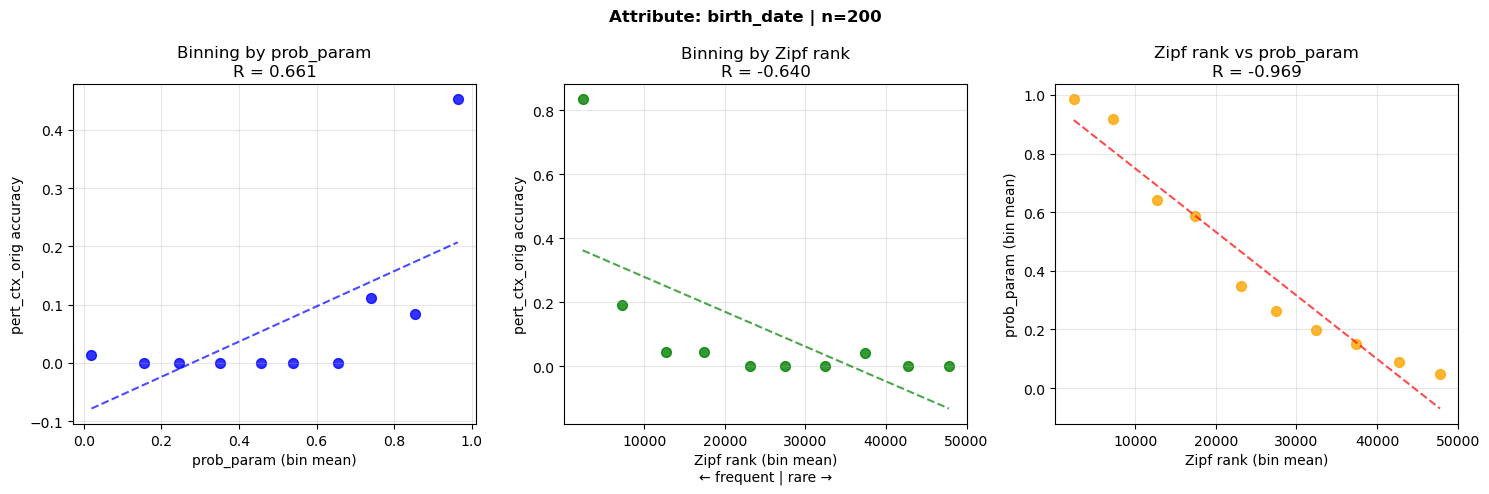

INFO:compare_binning:[birth_date] prob_param binning R = 0.6610
INFO:compare_binning:[birth_date] Zipf rank binning R = -0.6398
INFO:compare_binning:[birth_date] Zipf rank vs prob_param R = -0.9687


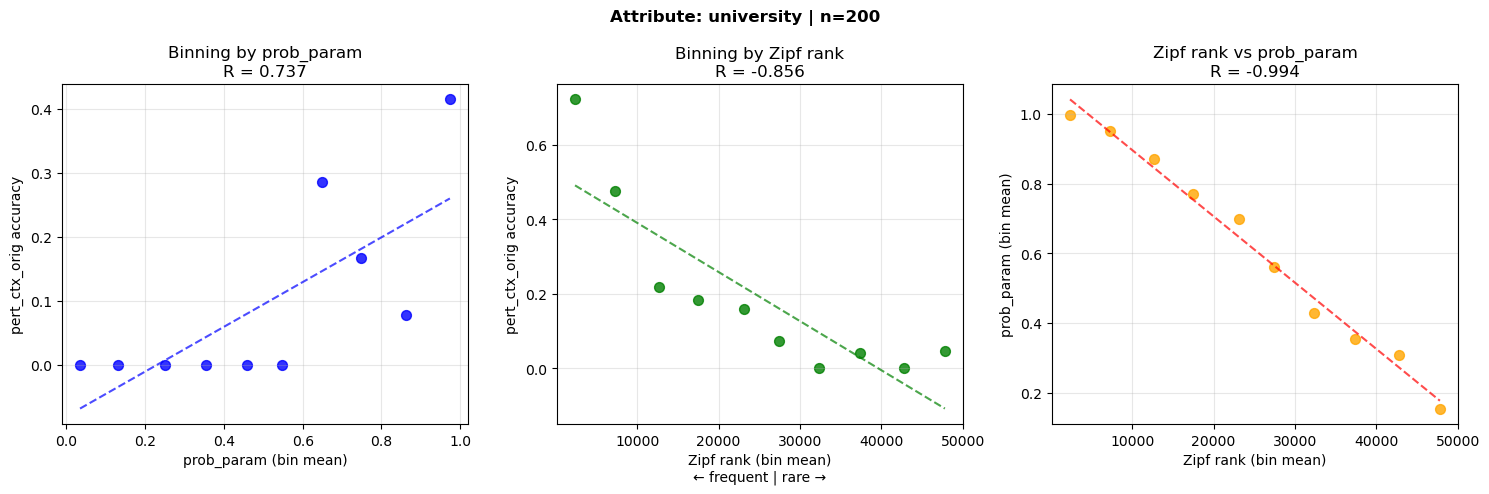

INFO:compare_binning:[university] prob_param binning R = 0.7365
INFO:compare_binning:[university] Zipf rank binning R = -0.8562
INFO:compare_binning:[university] Zipf rank vs prob_param R = -0.9938


In [3]:
#!/usr/bin/env python3
# ==========================================
# Binning comparison: prob_param vs Zipf rank
# - Analyze pert_ctx_orig accuracy with two binning methods
# - Side-by-side comparison plots
# ==========================================
import os, re, json, logging, gc, random
from pathlib import Path
from typing import List, Dict, Tuple, Optional

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from transformers import GPT2Tokenizer, GPT2LMHeadModel

# ---------- Logging/Seed ----------
logging.basicConfig(level=logging.INFO)
log = logging.getLogger("compare_binning")
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

# ---------- User settings ----------
MODEL_ROOT = Path("./gpt2_runs_0816")
RUN_DIR_NAME_FILTER: Optional[str] = "100_1"
CKPT_STEP_FIXED = 16000

TRAIN_JSON = "../dataset_generation/bioS_train_250806.json"
TRAIN_PERT_JSON = "../dataset_generation/bioS_train_250806_pert.json"

ATTR_KEYS = ["birth_date", "university"]

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

SAMPLE_SIZE = 200
ZIPF_PERM_JSON: Optional[str] = None

# ---------- Common utilities ----------
def load_json(path: str):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

def list_run_dirs(root: Path, name_filter: Optional[str]):
    runs = []
    for p in root.iterdir():
        if p.is_dir() and (name_filter is None or name_filter in p.name):
            if any(child.is_dir() and child.name.startswith("checkpoint") for child in p.iterdir()):
                runs.append(p)
    runs.sort(key=lambda x: x.name)
    return runs

def list_ckpts_in_range(model_dir: Path, lo: int = 0, hi: int = 10**12):
    cand = []
    for p in model_dir.iterdir():
        if p.is_dir() and p.name.startswith("checkpoint"):
            m = re.findall(r"\d+", p.name)
            if not m:
                continue
            step = int(m[0])
            if lo <= step <= hi:
                cand.append((step, p))
    return [p for step, p in sorted(cand, key=lambda x: x[0])]

def _get_first_present_key(d: dict, keys: List[str]):
    for k in keys:
        if k in d:
            return k
    return None

def split_train_into_o_p_lists(train_raw, fallback_pert_json):
    if isinstance(train_raw, dict):
        if "orig" in train_raw and "pert" in train_raw:
            return train_raw["orig"], train_raw["pert"]

    if isinstance(train_raw, list):
        o_list, p_list = [], []
        all_have = True
        for e in train_raw:
            tc_o = _get_first_present_key(e, ["test_corpus","orig_test_corpus","ctx","ctx_o"])
            pr_o = _get_first_present_key(e, ["probes","orig_probes"])

            if tc_o and pr_o:
                o_list.append({"test_corpus": e[tc_o], "probes": e[pr_o]})
            else:
                all_have = False
                break

            p_block = None
            if isinstance(e.get("pert"), dict):
                p_block = e["pert"]
            else:
                tc_p = _get_first_present_key(e, ["test_corpus_pert","pert_test_corpus","p_test_corpus","ctx_p"])
                pr_p = _get_first_present_key(e, ["probes_pert","pert_probes","p_probes"])
                if tc_p and pr_p:
                    p_block = {"test_corpus": e[tc_p], "probes": e[pr_p]}

            if p_block:
                p_list.append({"test_corpus": p_block["test_corpus"], "probes": p_block["probes"]})
            else:
                all_have = False

        if all_have and len(o_list) == len(p_list) > 0:
            return o_list, p_list

    pert_raw = load_json(fallback_pert_json)
    return train_raw, pert_raw

def load_zipf_perm_or_identity(n: int, perm_json: Optional[str]) -> List[int]:
    if perm_json is None:
        return list(range(n))
    perm = load_json(perm_json)
    assert isinstance(perm, list) and len(perm) == n
    return perm

def build_idx_to_rank(rank_to_idx: List[int]) -> Dict[int, int]:
    return {idx: rank for rank, idx in enumerate(rank_to_idx)}

def build_mode_texts(o, p, attr):
    ctx_p = p["test_corpus"]
    prompt_o, tgt_o = o["probes"][attr]

    return {
        "param": (" " + prompt_o, " " + prompt_o + tgt_o),
        "pert_ctx_orig": (" " + ctx_p + " " + prompt_o,
                          " " + ctx_p + " " + prompt_o + tgt_o),
    }

def find_ckpt_at_step(root, name_filter, step):
    runs = list_run_dirs(root, name_filter)
    cand = []
    for run_dir in runs:
        c = run_dir / f"checkpoint-{step}"
        if c.is_dir():
            cand.append((c.stat().st_mtime, run_dir.name, c))
        else:
            for p in list_ckpts_in_range(run_dir, step, step):
                cand.append((p.stat().st_mtime, run_dir.name, p))
    if not cand:
        raise FileNotFoundError("checkpoint not found")
    cand.sort(key=lambda x: x[0], reverse=True)
    return cand[0][1], cand[0][2]

@torch.inference_mode()
def full_target_prob_and_exact_match(model, tok, prompt_text, full_text):
    max_len = getattr(model.config, "n_ctx", getattr(model.config, "n_positions", 1024))
    ids = tok(full_text, truncation=True, max_length=max_len,
              return_tensors="pt").input_ids.to(DEVICE)
    logits = model(ids).logits.squeeze(0)
    pl = len(tok(prompt_text)["input_ids"])
    tgt_ids = ids.squeeze(0)[pl:]

    prob_product = 1.0
    exact_match = True

    for i in range(len(tgt_ids)):
        pos = pl + i - 1
        logits_pos = logits[pos]
        probs = F.softmax(logits_pos, dim=-1)
        tid = tgt_ids[i].item()
        p = probs[tid].item()
        prob_product *= max(p, 1e-38)

        pred_id = logits_pos.argmax(dim=-1).item()
        if pred_id != tid:
            exact_match = False

    return float(prob_product), bool(exact_match)

# ---------- Binning helper ----------
def compute_binned_stats(x_vals, y_vals, num_bins=10):
    """Bin by x_vals, return x mean and y mean per bin"""
    mask = np.isfinite(x_vals) & np.isfinite(y_vals)
    x = x_vals[mask]
    y = y_vals[mask]

    if len(x) < 2:
        return None, None, None, None

    x_min, x_max = x.min(), x.max()
    if x_min == x_max:
        return None, None, None, None

    bins = np.linspace(x_min, x_max, num_bins + 1)
    bin_idx = np.digitize(x, bins, right=False) - 1
    bin_idx = np.clip(bin_idx, 0, num_bins - 1)

    bin_x_means = []
    bin_y_means = []
    bin_counts = []

    for b in range(num_bins):
        mask_b = bin_idx == b
        if not np.any(mask_b):
            continue
        bin_x_means.append(x[mask_b].mean())
        bin_y_means.append(y[mask_b].mean())
        bin_counts.append(mask_b.sum())

    bin_x_means = np.array(bin_x_means)
    bin_y_means = np.array(bin_y_means)

    if len(bin_x_means) < 2:
        return None, None, None, None

    R = np.corrcoef(bin_x_means, bin_y_means)[0, 1]
    return bin_x_means, bin_y_means, bin_counts, R

# ---------- Main ----------
def run_comparison():
    log.info("Loading data & tokenizer...")

    tok = GPT2Tokenizer.from_pretrained("gpt2")
    tok.pad_token = tok.eos_token

    raw = load_json(TRAIN_JSON)
    o_raw, p_raw = split_train_into_o_p_lists(raw, TRAIN_PERT_JSON)

    n_entities = len(o_raw)
    log.info(f"Total entities: {n_entities}")

    rank_to_idx = load_zipf_perm_or_identity(n_entities, ZIPF_PERM_JSON)
    idx_to_rank = build_idx_to_rank(rank_to_idx)

    all_indices = list(range(n_entities))
    if n_entities > SAMPLE_SIZE:
        sampled_indices = sorted(random.sample(all_indices, SAMPLE_SIZE))
        log.info(f"Sampled {SAMPLE_SIZE} entities")
    else:
        sampled_indices = all_indices

    run_name, ckpt_path = find_ckpt_at_step(MODEL_ROOT, RUN_DIR_NAME_FILTER, CKPT_STEP_FIXED)
    log.info(f"Using checkpoint: {run_name} | {ckpt_path}")

    model = GPT2LMHeadModel.from_pretrained(ckpt_path).to(DEVICE).eval()

    rows = []
    for ent_idx in tqdm(sampled_indices, desc="Computing"):
        o = o_raw[ent_idx]
        p = p_raw[ent_idx]
        zipf_rank = idx_to_rank[ent_idx]

        for attr in ATTR_KEYS:
            texts = build_mode_texts(o, p, attr)

            prm_pr, prm_full = texts["param"]
            prob_param, exact_param = full_target_prob_and_exact_match(model, tok, prm_pr, prm_full)

            pt_pr, pt_full = texts["pert_ctx_orig"]
            prob_pert_orig, exact_pert_orig = full_target_prob_and_exact_match(model, tok, pt_pr, pt_full)

            rows.append({
                "entity_idx": ent_idx,
                "zipf_rank": zipf_rank,
                "attr": attr,
                "prob_param": prob_param,
                "correct_param": int(exact_param),
                "correct_pert_ctx_orig": int(exact_pert_orig),
            })

    del model
    if DEVICE == "cuda":
        torch.cuda.empty_cache()
    gc.collect()

    df = pd.DataFrame(rows)

    # ---- Comparative analysis ----
    NUM_BINS = 10

    for attr in ATTR_KEYS:
        sub = df[df["attr"] == attr].copy()

        zipf_ranks = sub["zipf_rank"].values
        prob_params = sub["prob_param"].values
        acc_flags = sub["correct_pert_ctx_orig"].values.astype(float)

        # Binning 1: by prob_param
        bx_prob, by_prob, bc_prob, R_prob = compute_binned_stats(prob_params, acc_flags, NUM_BINS)

        # Binning 2: by zipf_rank
        bx_zipf, by_zipf, bc_zipf, R_zipf = compute_binned_stats(zipf_ranks, acc_flags, NUM_BINS)

        # Zipf rank vs prob_param correlation
        bx_zp, by_zp, _, R_zipf_prob = compute_binned_stats(zipf_ranks, prob_params, NUM_BINS)

        # ---- Comparison plots ----
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))

        # Plot 1: binning by prob_param
        ax1 = axes[0]
        if bx_prob is not None:
            coef = np.polyfit(bx_prob, by_prob, 1)
            x_line = np.linspace(bx_prob.min(), bx_prob.max(), 100)
            y_line = np.polyval(coef, x_line)

            ax1.scatter(bx_prob, by_prob, s=50, alpha=0.8, c='blue')
            ax1.plot(x_line, y_line, 'b--', alpha=0.7)
            ax1.set_xlabel("prob_param (bin mean)")
            ax1.set_ylabel("pert_ctx_orig accuracy")
            ax1.set_title(f"Binning by prob_param\nR = {R_prob:.3f}")
        else:
            ax1.set_title("prob_param binning failed")
        ax1.grid(alpha=0.3)

        # Plot 2: binning by zipf_rank
        ax2 = axes[1]
        if bx_zipf is not None:
            coef = np.polyfit(bx_zipf, by_zipf, 1)
            x_line = np.linspace(bx_zipf.min(), bx_zipf.max(), 100)
            y_line = np.polyval(coef, x_line)

            ax2.scatter(bx_zipf, by_zipf, s=50, alpha=0.8, c='green')
            ax2.plot(x_line, y_line, 'g--', alpha=0.7)
            ax2.set_xlabel("Zipf rank (bin mean)\n← frequent | rare →")
            ax2.set_ylabel("pert_ctx_orig accuracy")
            ax2.set_title(f"Binning by Zipf rank\nR = {R_zipf:.3f}")
        else:
            ax2.set_title("Zipf rank binning failed")
        ax2.grid(alpha=0.3)

        # Plot 3: Zipf rank vs prob_param
        ax3 = axes[2]
        if bx_zp is not None:
            coef = np.polyfit(bx_zp, by_zp, 1)
            x_line = np.linspace(bx_zp.min(), bx_zp.max(), 100)
            y_line = np.polyval(coef, x_line)

            ax3.scatter(bx_zp, by_zp, s=50, alpha=0.8, c='orange')
            ax3.plot(x_line, y_line, 'r--', alpha=0.7)
            ax3.set_xlabel("Zipf rank (bin mean)")
            ax3.set_ylabel("prob_param (bin mean)")
            ax3.set_title(f"Zipf rank vs prob_param\nR = {R_zipf_prob:.3f}")
        else:
            ax3.set_title("Zipf-prob correlation failed")
        ax3.grid(alpha=0.3)

        fig.suptitle(f"Attribute: {attr} | n={len(sub)}", fontsize=12, fontweight='bold')
        plt.tight_layout()
        plt.show()

        # Log output
        log.info(f"[{attr}] prob_param binning R = {R_prob:.4f}" if R_prob else f"[{attr}] prob_param binning failed")
        log.info(f"[{attr}] Zipf rank binning R = {R_zipf:.4f}" if R_zipf else f"[{attr}] Zipf rank binning failed")
        log.info(f"[{attr}] Zipf rank vs prob_param R = {R_zipf_prob:.4f}" if R_zipf_prob else f"[{attr}] Zipf-prob correlation failed")

    return df

# ====== Execution ======
df_result = run_comparison()

INFO:fullprob_param_vs_pert_orig_nolog:Loading data & tokenizer...
INFO:fullprob_param_vs_pert_orig_nolog:Total entities: 50000
INFO:fullprob_param_vs_pert_orig_nolog:Using checkpoint: zipf_textlist_out_zipf_100_0_250816-104331 | gpt2_runs_0816/zipf_textlist_out_zipf_100_0_250816-104331/checkpoint-16000
Computing full probs: 100%|██████████| 50000/50000 [21:49<00:00, 38.19it/s]
INFO:fullprob_param_vs_pert_orig_nolog:Saved CSV: fullprob_PARAMvsPERTctxORIG_ALL_noLOG_step16000_zipf_textlist_out_zipf_100_0_250816-104331.csv
INFO:fullprob_param_vs_pert_orig_nolog:[birth_date] Pearson R (binned prob_param vs pert_ctx_orig exact match acc) = 0.5335 (bins=10)


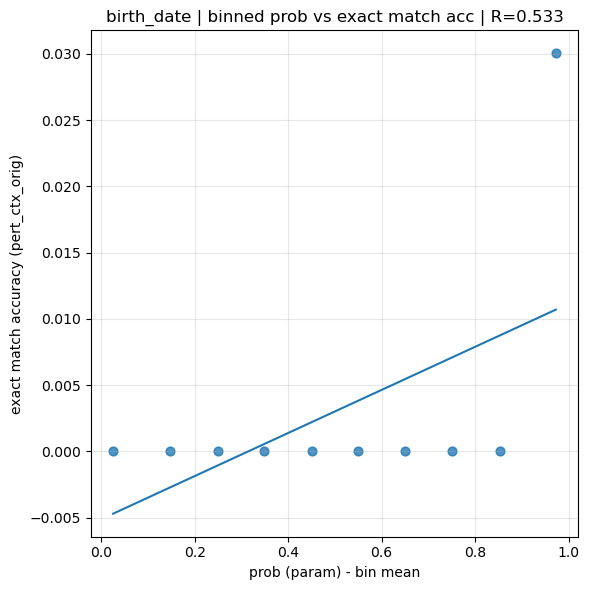

INFO:fullprob_param_vs_pert_orig_nolog:[university] Pearson R (binned prob_param vs pert_ctx_orig exact match acc) = 0.5542 (bins=10)


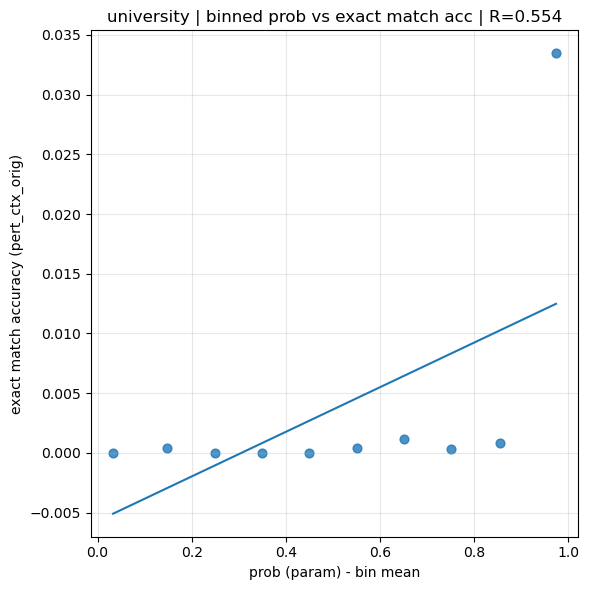

In [7]:
#!/usr/bin/env python3
# ==========================================
# Full cell: param vs pert_ctx_orig (full dataset, no log)
# - Use ALL entities (no rank sampling)
# - target probability = product of token probs (raw prob)
# - Final analysis:
#   * 10 bins based on prob_param
#   * Compute pert_ctx_orig exact match accuracy per bin
#   * Compute trend line + Pearson R from per-bin points
# ==========================================
import os, re, json, logging, gc, random
from pathlib import Path
from typing import List, Dict, Tuple, Optional

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from transformers import GPT2Tokenizer, GPT2LMHeadModel

# ---------- Logging/Seed ----------
logging.basicConfig(level=logging.INFO)
log = logging.getLogger("fullprob_param_vs_pert_orig_nolog")
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

# ---------- User settings ----------
MODEL_ROOT = Path("./gpt2_runs_0816")
RUN_DIR_NAME_FILTER: Optional[str] = "100_0"
CKPT_STEP_FIXED = 16000

TRAIN_JSON = "../dataset_generation/bioS_train_250806.json"
TRAIN_PERT_JSON = "../dataset_generation/bioS_train_250806_pert.json"

ATTR_KEYS  = ["birth_date", "university"]

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# ---------- Common utilities ----------
def load_json(path: str):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

def list_run_dirs(root: Path, name_filter: Optional[str]):
    runs = []
    for p in root.iterdir():
        if p.is_dir() and (name_filter is None or name_filter in p.name):
            if any(child.is_dir() and child.name.startswith("checkpoint") for child in p.iterdir()):
                runs.append(p)
    runs.sort(key=lambda x: x.name)
    return runs

def list_ckpts_in_range(model_dir: Path, lo: int = 0, hi: int = 10**12):
    cand = []
    for p in model_dir.iterdir():
        if p.is_dir() and p.name.startswith("checkpoint"):
            m = re.findall(r"\d+", p.name)
            if not m:
                continue
            step = int(m[0])
            if lo <= step <= hi:
                cand.append((step, p))
    return [p for step, p in sorted(cand, key=lambda x: x[0])]

def _get_first_present_key(d: dict, keys: List[str]):
    for k in keys:
        if k in d:
            return k
    return None

def split_train_into_o_p_lists(train_raw, fallback_pert_json):
    """Return (orig, pert) lists from train_raw."""
    # A format
    if isinstance(train_raw, dict):
        if "orig" in train_raw and "pert" in train_raw:
            return train_raw["orig"], train_raw["pert"]

    # B/C format
    if isinstance(train_raw, list):
        o_list, p_list = [], []
        all_have = True
        for e in train_raw:
            tc_o = _get_first_present_key(e, ["test_corpus","orig_test_corpus","ctx","ctx_o"])
            pr_o = _get_first_present_key(e, ["probes","orig_probes"])

            if tc_o and pr_o:
                o_list.append({"test_corpus": e[tc_o], "probes": e[pr_o]})
            else:
                all_have = False
                break

            # pert
            p_block = None
            if isinstance(e.get("pert"), dict):
                p_block = e["pert"]
            else:
                tc_p = _get_first_present_key(e, ["test_corpus_pert","pert_test_corpus","p_test_corpus","ctx_p"])
                pr_p = _get_first_present_key(e, ["probes_pert","pert_probes","p_probes"])
                if tc_p and pr_p:
                    p_block = {"test_corpus": e[tc_p], "probes": e[pr_p]}

            if p_block:
                p_list.append({"test_corpus": p_block["test_corpus"], "probes": p_block["probes"]})
            else:
                all_have = False

        if all_have and len(o_list) == len(p_list) > 0:
            return o_list, p_list

    # fallback
    pert_raw = load_json(fallback_pert_json)
    return train_raw, pert_raw

# ---------- Text construction ----------
def build_mode_texts(o, p, attr):
    ctx_p = p["test_corpus"]     # perturbed context
    ctx_o = o["test_corpus"]     # original context

    prompt_o, tgt_o = o["probes"][attr]
    prompt_p, tgt_p = p["probes"][attr]

    return {
        "param": ( " " + prompt_o, " " + prompt_o + tgt_o),

        # pert_ctx_orig mode:
        # context = ctx_p (perturbed), but prompt = prompt_o (original)
        "pert_ctx_orig": ( " " + ctx_p + " " + prompt_o,
                           " " + ctx_p + " " + prompt_o + tgt_o),
    }

# ---------- Checkpoint ----------
def find_ckpt_at_step(root, name_filter, step):
    runs = list_run_dirs(root, name_filter)
    cand = []
    for run_dir in runs:
        c = run_dir / f"checkpoint-{step}"
        if c.is_dir():
            cand.append((c.stat().st_mtime, run_dir.name, c))
        else:
            for p in list_ckpts_in_range(run_dir, step, step):
                cand.append((p.stat().st_mtime, run_dir.name, p))
    if not cand:
        raise FileNotFoundError("checkpoint not found")
    cand.sort(key=lambda x: x[0], reverse=True)
    return cand[0][1], cand[0][2]

# ---------- raw full target prob + exact match ----------
@torch.inference_mode()
def full_target_prob_and_exact_match(model, tok, prompt_text, full_text):
    """
    Returns the product of all target token probabilities and
    whether the argmax token sequence exactly matches the target (exact match).
    """
    max_len = getattr(model.config, "n_ctx", getattr(model.config, "n_positions", 1024))

    ids = tok(full_text, truncation=True, max_length=max_len,
              return_tensors="pt").input_ids.to(DEVICE)

    logits = model(ids).logits.squeeze(0)

    pl = len(tok(prompt_text)["input_ids"])
    tgt_ids = ids.squeeze(0)[pl:]

    prob_product = 1.0
    exact_match = True

    for i in range(len(tgt_ids)):
        pos = pl + i - 1
        logits_pos = logits[pos]

        # Probability (prob of the correct token)
        probs = F.softmax(logits_pos, dim=-1)
        tid = tgt_ids[i].item()
        p = probs[tid].item()
        prob_product *= max(p, 1e-38)  # lower bound to prevent underflow

        # Compare argmax token with target -> exact match
        pred_id = logits_pos.argmax(dim=-1).item()
        if pred_id != tid:
            exact_match = False

    return float(prob_product), bool(exact_match)

# ---------- Main ----------
def run_full_dataset_prob():
    log.info("Loading data & tokenizer...")

    tok = GPT2Tokenizer.from_pretrained("gpt2")
    tok.pad_token = tok.eos_token

    raw = load_json(TRAIN_JSON)
    o_raw, p_raw = split_train_into_o_p_lists(raw, TRAIN_PERT_JSON)

    n_entities = len(o_raw)
    log.info(f"Total entities: {n_entities}")

    run_name, ckpt_path = find_ckpt_at_step(MODEL_ROOT, RUN_DIR_NAME_FILTER, CKPT_STEP_FIXED)
    log.info(f"Using checkpoint: {run_name} | {ckpt_path}")

    model = GPT2LMHeadModel.from_pretrained(ckpt_path).to(DEVICE).eval()

    rows = []
    for ent_idx in tqdm(range(n_entities), desc="Computing full probs"):
        o = o_raw[ent_idx]
        p = p_raw[ent_idx]

        for attr in ATTR_KEYS:
            texts = build_mode_texts(o, p, attr)

            # ============= param mode =============
            prm_pr, prm_full = texts["param"]
            prob_param, exact_param = full_target_prob_and_exact_match(
                model, tok, prm_pr, prm_full
            )

            # ============= pert_ctx_orig mode =============
            pt_pr, pt_full = texts["pert_ctx_orig"]
            prob_pert_orig, exact_pert_orig = full_target_prob_and_exact_match(
                model, tok, pt_pr, pt_full
            )

            rows.append({
                "entity_idx": ent_idx,
                "attr": attr,
                "prob_param": prob_param,
                "prob_pert_ctx_orig": prob_pert_orig,   # not used in analysis but kept for reference
                "correct_param": int(exact_param),
                "correct_pert_ctx_orig": int(exact_pert_orig),
            })

    del model
    if DEVICE == "cuda":
        torch.cuda.empty_cache()
    gc.collect()

    df = pd.DataFrame(rows)

    out_csv = f"fullprob_PARAMvsPERTctxORIG_ALL_noLOG_step{CKPT_STEP_FIXED}_{run_name}.csv"
    df.to_csv(out_csv, index=False)
    log.info(f"Saved CSV: {out_csv}")

    # ---- Binning analysis + trend line + Pearson R (exact match accuracy) ----
    NUM_BINS = 10

    for attr in ATTR_KEYS:
        sub = df[df["attr"] == attr].copy()
        x = sub["prob_param"].values
        # exact match flag (0/1)
        acc_flags = sub["correct_pert_ctx_orig"].values.astype(float)

        mask = np.isfinite(x)
        x = x[mask]
        acc_flags = acc_flags[mask]

        if len(x) < 2:
            log.warning(f"[{attr}] Not enough samples for binning/correlation.")
            continue

        x_min, x_max = x.min(), x.max()
        if x_min == x_max:
            log.warning(f"[{attr}] prob_param has zero variance; skipping.")
            continue

        bins = np.linspace(x_min, x_max, NUM_BINS + 1)
        bin_idx = np.digitize(x, bins, right=False) - 1
        bin_idx = np.clip(bin_idx, 0, NUM_BINS - 1)

        bin_x_means = []
        bin_acc = []
        bin_counts = []

        for b in range(NUM_BINS):
            mask_b = bin_idx == b
            if not np.any(mask_b):
                continue
            xb = x[mask_b]
            ab = acc_flags[mask_b]

            bin_x_means.append(xb.mean())
            bin_acc.append(ab.mean())   # exact match accuracy (mean of 0/1)
            bin_counts.append(mask_b.sum())

        bin_x_means = np.array(bin_x_means)
        bin_acc = np.array(bin_acc)

        if len(bin_x_means) < 2:
            log.warning(f"[{attr}] Not enough non-empty bins for correlation.")
            continue

        # Pearson R (per bin)
        R = np.corrcoef(bin_x_means, bin_acc)[0, 1]
        log.info(
            f"[{attr}] Pearson R (binned prob_param vs pert_ctx_orig exact match acc) "
            f"= {R:.4f} (bins={len(bin_x_means)})"
        )

        # Linear regression trend line
        coef = np.polyfit(bin_x_means, bin_acc, 1)
        x_line = np.linspace(bin_x_means.min(), bin_x_means.max(), 100)
        y_line = np.polyval(coef, x_line)

        # Plot: per-bin points + trend line
        plt.figure(figsize=(6,6))
        plt.scatter(bin_x_means, bin_acc, s=40, alpha=0.8)
        plt.plot(x_line, y_line)
        plt.xlabel("prob (param) - bin mean")
        plt.ylabel("exact match accuracy (pert_ctx_orig)")
        plt.title(f"{attr} | binned prob vs exact match acc | R={R:.3f}")
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()

    return df

# ====== Execution ======
df_full = run_full_dataset_prob()


INFO:plot_binned_5bins:[birth_date] Pearson R (binned(5) prob_param vs pert_ctx_orig exact match acc) = 0.7809 (bins=5)


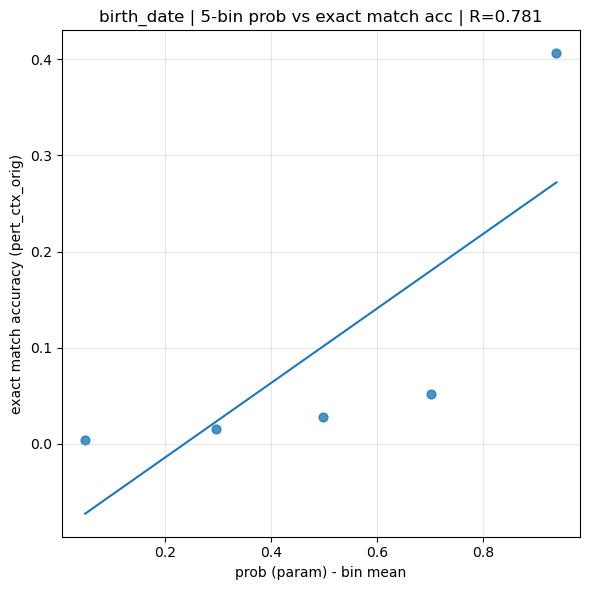

INFO:plot_binned_5bins:[university] Pearson R (binned(5) prob_param vs pert_ctx_orig exact match acc) = 0.8625 (bins=5)


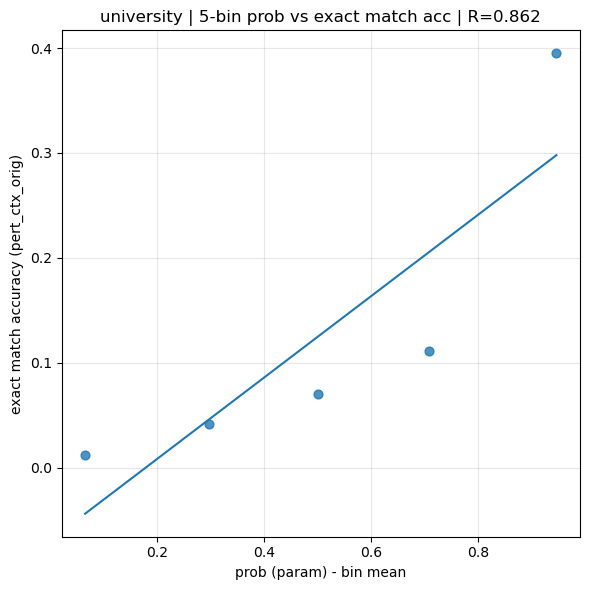

In [8]:
#!/usr/bin/env python3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import logging

logging.basicConfig(level=logging.INFO)
log = logging.getLogger("plot_binned_5bins")

# ===== Configuration =====
CSV_PATH = "fullprob_PARAMvsPERTctxORIG_ALL_noLOG_step16000_zipf_textlist_out_zipf_100_1_250816-151409.csv"  # Replace with your CSV file name
ATTR_KEYS = ["birth_date", "university"]
NUM_BINS = 5  # Set to 5 bins here

# ===== Load =====
df = pd.read_csv(CSV_PATH)

for attr in ATTR_KEYS:
    sub = df[df["attr"] == attr].copy()
    x = sub["prob_param"].values
    acc_flags = sub["correct_pert_ctx_orig"].values.astype(float)

    mask = np.isfinite(x)
    x = x[mask]
    acc_flags = acc_flags[mask]

    if len(x) < 2:
        log.warning(f"[{attr}] Not enough samples for binning/correlation.")
        continue

    x_min, x_max = x.min(), x.max()
    if x_min == x_max:
        log.warning(f"[{attr}] prob_param has zero variance; skipping.")
        continue

    # ----- bin = 5 -----
    bins = np.linspace(x_min, x_max, NUM_BINS + 1)
    bin_idx = np.digitize(x, bins, right=False) - 1
    bin_idx = np.clip(bin_idx, 0, NUM_BINS - 1)

    bin_x_means = []
    bin_acc = []
    bin_counts = []

    for b in range(NUM_BINS):
        mask_b = bin_idx == b
        if not np.any(mask_b):
            continue
        xb = x[mask_b]
        ab = acc_flags[mask_b]

        bin_x_means.append(xb.mean())
        bin_acc.append(ab.mean())
        bin_counts.append(mask_b.sum())

    bin_x_means = np.array(bin_x_means)
    bin_acc = np.array(bin_acc)

    if len(bin_x_means) < 2:
        log.warning(f"[{attr}] Not enough non-empty bins for correlation.")
        continue

    # Pearson R (per bin)
    R = np.corrcoef(bin_x_means, bin_acc)[0, 1]
    log.info(
        f"[{attr}] Pearson R (binned(5) prob_param vs pert_ctx_orig exact match acc) "
        f"= {R:.4f} (bins={len(bin_x_means)})"
    )

    # Linear regression trend line
    coef = np.polyfit(bin_x_means, bin_acc, 1)
    x_line = np.linspace(bin_x_means.min(), bin_x_means.max(), 100)
    y_line = np.polyval(coef, x_line)

    # Plot: per-bin points + trend line
    plt.figure(figsize=(6,6))
    plt.scatter(bin_x_means, bin_acc, s=40, alpha=0.8)
    plt.plot(x_line, y_line)
    plt.xlabel("prob (param) - bin mean")
    plt.ylabel("exact match accuracy (pert_ctx_orig)")
    plt.title(f"{attr} | 5-bin prob vs exact match acc | R={R:.3f}")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


INFO:plot_binned_5bins_compare:[birth_date] run 100_1: Pearson R (5-bin prob_param vs pert_ctx_orig exact match acc) = 0.6717 (bins=10)
INFO:plot_binned_5bins_compare:[birth_date] run 100_0: Pearson R (5-bin prob_param vs pert_ctx_orig exact match acc) = 0.5335 (bins=10)
/tmp/ipykernel_2772061/415586409.py:128: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2772061/415586409.py:128: UserWarning: Glyph 44368 (\N{HANGUL SYLLABLE GYO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/minsungkim/.conda/envs/fact/lib/python3.12/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/minsungkim/.conda/envs/fact/lib/python3.12/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 44368 (\N{HANGUL SYLLABLE GYO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io

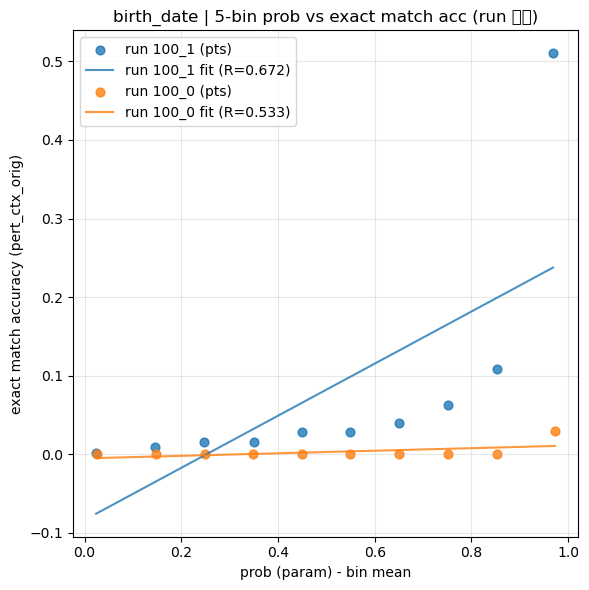

INFO:plot_binned_5bins_compare:[university] run 100_1: Pearson R (5-bin prob_param vs pert_ctx_orig exact match acc) = 0.7897 (bins=10)
INFO:plot_binned_5bins_compare:[university] run 100_0: Pearson R (5-bin prob_param vs pert_ctx_orig exact match acc) = 0.5542 (bins=10)


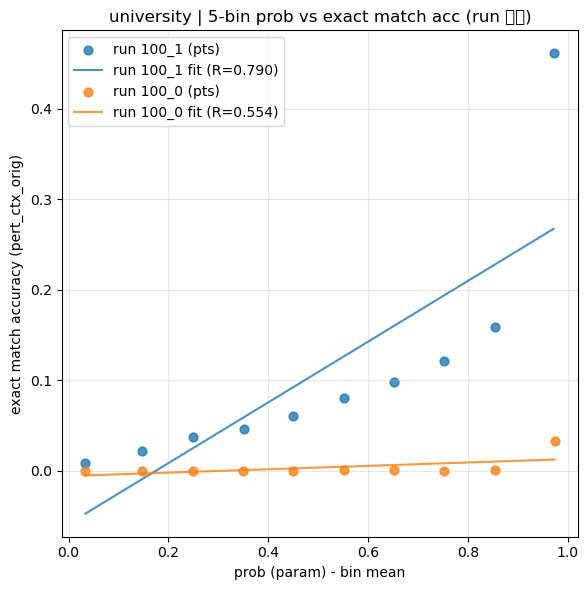

In [10]:
#!/usr/bin/env python3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import logging

logging.basicConfig(level=logging.INFO)
log = logging.getLogger("plot_binned_5bins_compare")

# ===== Configuration =====
CSV_INFOS = [
    {
        "path": "fullprob_PARAMvsPERTctxORIG_ALL_noLOG_step16000_zipf_textlist_out_zipf_100_1_250816-151409.csv",
        "label": "run 100_1",
    },
    {
        "path": "fullprob_PARAMvsPERTctxORIG_ALL_noLOG_step16000_zipf_textlist_out_zipf_100_0_250816-104331.csv",
        "label": "run 100_0",
    },
]
ATTR_KEYS = ["birth_date", "university"]
NUM_BINS = 10  # Common bin count

# ===== Load =====
dfs = []
for info in CSV_INFOS:
    df = pd.read_csv(info["path"])
    dfs.append(df)

# ===== Per-attribute comparison plot =====
for attr in ATTR_KEYS:
    # Collect data from each run to determine the overall x range first
    all_x = []

    per_run_data = []  # Save for later reuse
    for info, df in zip(CSV_INFOS, dfs):
        sub = df[df["attr"] == attr].copy()

        if "prob_param" not in sub.columns or "correct_pert_ctx_orig" not in sub.columns:
            log.warning(f"[{attr}] {info['path']} is missing required columns. (prob_param, correct_pert_ctx_orig)")
            continue

        x = sub["prob_param"].values
        acc_flags = sub["correct_pert_ctx_orig"].values.astype(float)

        mask = np.isfinite(x)
        x = x[mask]
        acc_flags = acc_flags[mask]

        if len(x) < 2:
            log.warning(f"[{attr}] {info['label']} has insufficient samples.")
            continue

        per_run_data.append({
            "label": info["label"],
            "x": x,
            "acc_flags": acc_flags,
        })
        all_x.append(x)

    if not per_run_data:
        log.warning(f"[{attr}] No valid run data available.")
        continue

    # Set common bin range
    all_x_concat = np.concatenate(all_x)
    x_min, x_max = all_x_concat.min(), all_x_concat.max()
    if x_min == x_max:
        log.warning(f"[{attr}] prob_param is constant across all runs; skipping.")
        continue

    bins = np.linspace(x_min, x_max, NUM_BINS + 1)

    plt.figure(figsize=(6, 6))

    # Binning + plot per run
    for run_data in per_run_data:
        label = run_data["label"]
        x = run_data["x"]
        acc_flags = run_data["acc_flags"]

        bin_idx = np.digitize(x, bins, right=False) - 1
        bin_idx = np.clip(bin_idx, 0, NUM_BINS - 1)

        bin_x_means = []
        bin_acc = []
        bin_counts = []

        for b in range(NUM_BINS):
            mask_b = bin_idx == b
            if not np.any(mask_b):
                continue
            xb = x[mask_b]
            ab = acc_flags[mask_b]

            bin_x_means.append(xb.mean())
            bin_acc.append(ab.mean())
            bin_counts.append(mask_b.sum())

        bin_x_means = np.array(bin_x_means)
        bin_acc = np.array(bin_acc)

        if len(bin_x_means) < 2:
            log.warning(f"[{attr}] {label}: fewer than 2 non-empty bins.")
            continue

        # Pearson R (per bin)
        R = np.corrcoef(bin_x_means, bin_acc)[0, 1]
        log.info(
            f"[{attr}] {label}: Pearson R (5-bin prob_param vs pert_ctx_orig exact match acc) "
            f"= {R:.4f} (bins={len(bin_x_means)})"
        )

        # Linear regression trend line
        coef = np.polyfit(bin_x_means, bin_acc, 1)
        x_line = np.linspace(bin_x_means.min(), bin_x_means.max(), 100)
        y_line = np.polyval(coef, x_line)

        # Plot: per-bin points + trend line (different label per run)
        plt.scatter(bin_x_means, bin_acc, s=40, alpha=0.8, label=f"{label} (pts)")
        plt.plot(x_line, y_line, alpha=0.8, label=f"{label} fit (R={R:.3f})")

    plt.xlabel("prob (param) - bin mean")
    plt.ylabel("exact match accuracy (pert_ctx_orig)")
    plt.title(f"{attr} | 5-bin prob vs exact match acc (run comparison)")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


INFO:fullprob_param_vs_pert_orig_nolog:Loading data & tokenizer...
INFO:fullprob_param_vs_pert_orig_nolog:Total entities: 50000
INFO:fullprob_param_vs_pert_orig_nolog:Using checkpoint: /home/minsungkim/workspace/mpi-sp/gpt2train/gpt2_runs_posttrain/posttrain_T1000_U0_clean_IT_ctxNoise0.000_attrMut0.100_sft_251129-061557/_final
Computing full probs: 100%|██████████| 50000/50000 [21:36<00:00, 38.57it/s]
INFO:fullprob_param_vs_pert_orig_nolog:Saved CSV: fullprob_PARAMvsPERTctxORIG_ALL_noLOG__final_direct.csv
INFO:fullprob_param_vs_pert_orig_nolog:[birth_date] Pearson R (binned prob_param vs pert_ctx_orig exact match acc) = 0.5357 (bins=10)


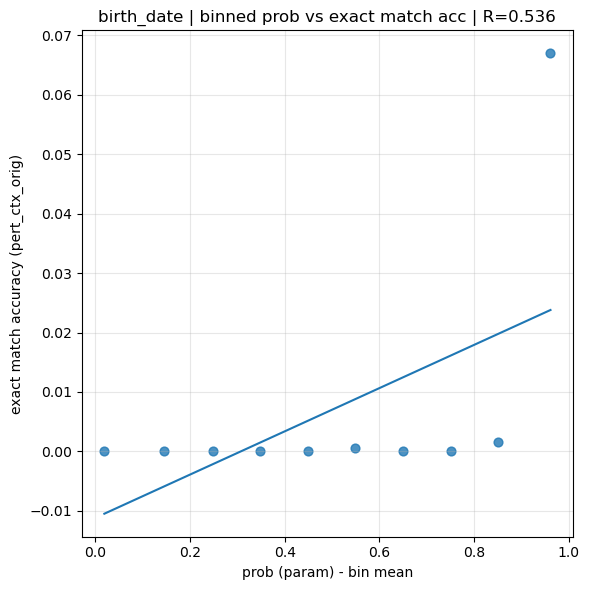

INFO:fullprob_param_vs_pert_orig_nolog:[university] Pearson R (binned prob_param vs pert_ctx_orig exact match acc) = 0.5659 (bins=10)


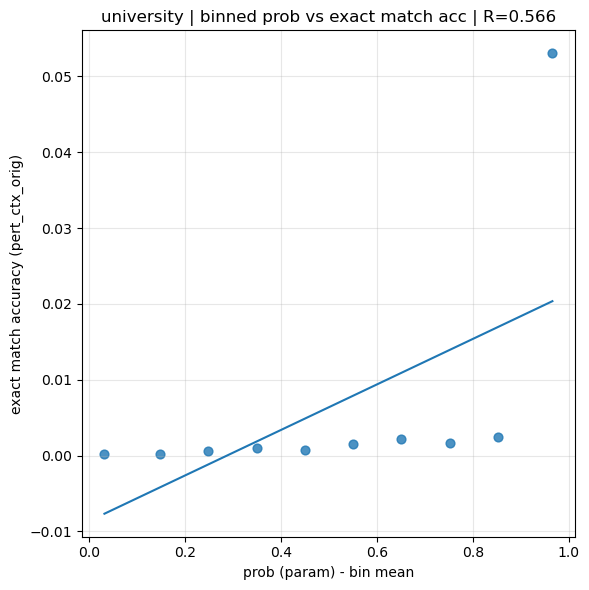

In [12]:
#!/usr/bin/env python3
# ==========================================
# Full cell: param vs pert_ctx_orig (full dataset, no log)
# - Use ALL entities (no rank sampling)
# - target probability = product of token probs (raw prob)
# - Final analysis:
#   * 10 bins based on prob_param
#   * Compute pert_ctx_orig exact match accuracy per bin
#   * Compute trend line + Pearson R from per-bin points
# ==========================================
import os, re, json, logging, gc, random
from pathlib import Path
from typing import List, Dict, Tuple, Optional

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from transformers import GPT2Tokenizer, GPT2LMHeadModel

# ---------- Logging/Seed ----------
logging.basicConfig(level=logging.INFO)
log = logging.getLogger("fullprob_param_vs_pert_orig_nolog")
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

# ---------- User settings ----------
MODEL_ROOT = Path("/home/minsungkim/workspace/mpi-sp/gpt2train/gpt2_runs_posttrain/posttrain_T1000_U0_clean_IT_ctxNoise0.000_attrMut0.100_sft_251129-061557")
RUN_DIR_NAME_FILTER: Optional[str] = "_final"
CKPT_STEP_FIXED = 16000  # Not currently used, kept for reference

TRAIN_JSON = "../dataset_generation/bioS_train_250806.json"
TRAIN_PERT_JSON = "../dataset_generation/bioS_train_250806_pert.json"

ATTR_KEYS  = ["birth_date", "university"]

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# ---------- Common utilities ----------
def load_json(path: str):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

def list_run_dirs(root: Path, name_filter: Optional[str]):
    runs = []
    for p in root.iterdir():
        if p.is_dir() and (name_filter is None or name_filter in p.name):
            if any(child.is_dir() and child.name.startswith("checkpoint") for child in p.iterdir()):
                runs.append(p)
    runs.sort(key=lambda x: x.name)
    return runs

def list_ckpts_in_range(model_dir: Path, lo: int = 0, hi: int = 10**12):
    cand = []
    for p in model_dir.iterdir():
        if p.is_dir() and p.name.startswith("checkpoint"):
            m = re.findall(r"\d+", p.name)
            if not m:
                continue
            step = int(m[0])
            if lo <= step <= hi:
                cand.append((step, p))
    return [p for step, p in sorted(cand, key=lambda x: x[0])]

def _get_first_present_key(d: dict, keys: List[str]):
    for k in keys:
        if k in d:
            return k
    return None

def split_train_into_o_p_lists(train_raw, fallback_pert_json):
    """Return (orig, pert) lists from train_raw."""
    # A format
    if isinstance(train_raw, dict):
        if "orig" in train_raw and "pert" in train_raw:
            return train_raw["orig"], train_raw["pert"]

    # B/C format
    if isinstance(train_raw, list):
        o_list, p_list = [], []
        all_have = True
        for e in train_raw:
            tc_o = _get_first_present_key(e, ["test_corpus","orig_test_corpus","ctx","ctx_o"])
            pr_o = _get_first_present_key(e, ["probes","orig_probes"])

            if tc_o and pr_o:
                o_list.append({"test_corpus": e[tc_o], "probes": e[pr_o]})
            else:
                all_have = False
                break

            # pert
            p_block = None
            if isinstance(e.get("pert"), dict):
                p_block = e["pert"]
            else:
                tc_p = _get_first_present_key(e, ["test_corpus_pert","pert_test_corpus","p_test_corpus","ctx_p"])
                pr_p = _get_first_present_key(e, ["probes_pert","pert_probes","p_probes"])
                if tc_p and pr_p:
                    p_block = {"test_corpus": e[tc_p], "probes": e[pr_p]}

            if p_block:
                p_list.append({"test_corpus": p_block["test_corpus"], "probes": p_block["probes"]})
            else:
                all_have = False

        if all_have and len(o_list) == len(p_list) > 0:
            return o_list, p_list

    # fallback
    pert_raw = load_json(fallback_pert_json)
    return train_raw, pert_raw

# ---------- Text construction ----------
def build_mode_texts(o, p, attr):
    ctx_p = p["test_corpus"]     # perturbed context
    ctx_o = o["test_corpus"]     # original context

    prompt_o, tgt_o = o["probes"][attr]
    prompt_p, tgt_p = p["probes"][attr]

    return {
        "param": ( " " + prompt_o, " " + prompt_o + tgt_o),

        # pert_ctx_orig mode:
        # context = ctx_p (perturbed), but prompt = prompt_o (original)
        "pert_ctx_orig": ( " " + ctx_p + " " + prompt_o,
                           " " + ctx_p + " " + prompt_o + tgt_o),
    }

# ---------- Checkpoint (not currently used, for reference) ----------
def find_ckpt_at_step(root, name_filter, step):
    runs = list_run_dirs(root, name_filter)
    cand = []
    for run_dir in runs:
        c = run_dir / f"checkpoint-{step}"
        if c.is_dir():
            cand.append((c.stat().st_mtime, run_dir.name, c))
        else:
            for p in list_ckpts_in_range(run_dir, step, step):
                cand.append((p.stat().st_mtime, run_dir.name, p))
    if not cand:
        raise FileNotFoundError("checkpoint not found")
    cand.sort(key=lambda x: x[0], reverse=True)
    return cand[0][1], cand[0][2]

# ---------- raw full target prob + exact match ----------
@torch.inference_mode()
def full_target_prob_and_exact_match(model, tok, prompt_text, full_text):
    """
    Returns the product of all target token probabilities and
    whether the argmax token sequence exactly matches the target (exact match).
    """
    max_len = getattr(model.config, "n_ctx", getattr(model.config, "n_positions", 1024))

    ids = tok(full_text, truncation=True, max_length=max_len,
              return_tensors="pt").input_ids.to(DEVICE)

    logits = model(ids).logits.squeeze(0)

    pl = len(tok(prompt_text)["input_ids"])
    tgt_ids = ids.squeeze(0)[pl:]

    prob_product = 1.0
    exact_match = True

    for i in range(len(tgt_ids)):
        pos = pl + i - 1
        logits_pos = logits[pos]

        # Probability (prob of the correct token)
        probs = F.softmax(logits_pos, dim=-1)
        tid = tgt_ids[i].item()
        p = probs[tid].item()
        prob_product *= max(p, 1e-38)  # lower bound to prevent underflow

        # Compare argmax token with target -> exact match
        pred_id = logits_pos.argmax(dim=-1).item()
        if pred_id != tid:
            exact_match = False

    return float(prob_product), bool(exact_match)

# ---------- Main ----------
def run_full_dataset_prob():
    log.info("Loading data & tokenizer...")

    tok = GPT2Tokenizer.from_pretrained("gpt2")
    tok.pad_token = tok.eos_token

    raw = load_json(TRAIN_JSON)
    o_raw, p_raw = split_train_into_o_p_lists(raw, TRAIN_PERT_JSON)

    n_entities = len(o_raw)
    log.info(f"Total entities: {n_entities}")

    # ============================
    # Directly specify checkpoint
    # ============================
    ckpt_path = "/home/minsungkim/workspace/mpi-sp/gpt2train/gpt2_runs_posttrain/posttrain_T1000_U0_clean_IT_ctxNoise0.000_attrMut0.100_sft_251129-061557/_final"
    run_name = "_final_direct"

    log.info(f"Using checkpoint: {ckpt_path}")
    model = GPT2LMHeadModel.from_pretrained(ckpt_path).to(DEVICE).eval()

    rows = []
    for ent_idx in tqdm(range(n_entities), desc="Computing full probs"):
        o = o_raw[ent_idx]
        p = p_raw[ent_idx]

        for attr in ATTR_KEYS:
            texts = build_mode_texts(o, p, attr)

            # ============= param mode =============
            prm_pr, prm_full = texts["param"]
            prob_param, exact_param = full_target_prob_and_exact_match(
                model, tok, prm_pr, prm_full
            )

            # ============= pert_ctx_orig mode =============
            pt_pr, pt_full = texts["pert_ctx_orig"]
            prob_pert_orig, exact_pert_orig = full_target_prob_and_exact_match(
                model, tok, pt_pr, pt_full
            )

            rows.append({
                "entity_idx": ent_idx,
                "attr": attr,
                "prob_param": prob_param,
                "prob_pert_ctx_orig": prob_pert_orig,   # not used in analysis but kept for reference
                "correct_param": int(exact_param),
                "correct_pert_ctx_orig": int(exact_pert_orig),
            })

    del model
    if DEVICE == "cuda":
        torch.cuda.empty_cache()
    gc.collect()

    df = pd.DataFrame(rows)

    out_csv = f"fullprob_PARAMvsPERTctxORIG_ALL_noLOG_{run_name}.csv"
    df.to_csv(out_csv, index=False)
    log.info(f"Saved CSV: {out_csv}")

    # ---- Binning analysis + trend line + Pearson R (exact match accuracy) ----
    NUM_BINS = 10

    for attr in ATTR_KEYS:
        sub = df[df["attr"] == attr].copy()
        x = sub["prob_param"].values
        # exact match flag (0/1)
        acc_flags = sub["correct_pert_ctx_orig"].values.astype(float)

        mask = np.isfinite(x)
        x = x[mask]
        acc_flags = acc_flags[mask]

        if len(x) < 2:
            log.warning(f"[{attr}] Not enough samples for binning/correlation.")
            continue

        x_min, x_max = x.min(), x.max()
        if x_min == x_max:
            log.warning(f"[{attr}] prob_param has zero variance; skipping.")
            continue

        bins = np.linspace(x_min, x_max, NUM_BINS + 1)
        bin_idx = np.digitize(x, bins, right=False) - 1
        bin_idx = np.clip(bin_idx, 0, NUM_BINS - 1)

        bin_x_means = []
        bin_acc = []
        bin_counts = []

        for b in range(NUM_BINS):
            mask_b = bin_idx == b
            if not np.any(mask_b):
                continue
            xb = x[mask_b]
            ab = acc_flags[mask_b]

            bin_x_means.append(xb.mean())
            bin_acc.append(ab.mean())   # exact match accuracy (mean of 0/1)
            bin_counts.append(mask_b.sum())

        bin_x_means = np.array(bin_x_means)
        bin_acc = np.array(bin_acc)

        if len(bin_x_means) < 2:
            log.warning(f"[{attr}] Not enough non-empty bins for correlation.")
            continue

        # Pearson R (per bin)
        R = np.corrcoef(bin_x_means, bin_acc)[0, 1]
        log.info(
            f"[{attr}] Pearson R (binned prob_param vs pert_ctx_orig exact match acc) "
            f"= {R:.4f} (bins={len(bin_x_means)})"
        )

        # Linear regression trend line
        coef = np.polyfit(bin_x_means, bin_acc, 1)
        x_line = np.linspace(bin_x_means.min(), bin_x_means.max(), 100)
        y_line = np.polyval(coef, x_line)

        # Plot: per-bin points + trend line
        plt.figure(figsize=(6,6))
        plt.scatter(bin_x_means, bin_acc, s=40, alpha=0.8)
        plt.plot(x_line, y_line)
        plt.xlabel("prob (param) - bin mean")
        plt.ylabel("exact match accuracy (pert_ctx_orig)")
        plt.title(f"{attr} | binned prob vs exact match acc | R={R:.3f}")
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()

    return df

# ====== Execution ======
df_full = run_full_dataset_prob()


In [ ]:
#!/usr/bin/env python3
# ==========================================
# Full cell: param vs pert_ctx_orig (full dataset, no log)
# - Use ALL entities (no rank sampling)
# - target probability = product of token probs (raw prob)
# - 10 bins based on prob_param
# - Compute pert_ctx_orig exact match accuracy per bin
# - Compute trend line + Pearson R from per-bin points
# - Iterate over all *_sft_*/_final models under gpt2_runs_posttrain_grid
# - Save per-model CSV/plot + overall summary CSV
# ==========================================
import os, re, json, logging, gc, random
from pathlib import Path
from typing import List, Dict, Tuple, Optional

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from transformers import GPT2Tokenizer, GPT2LMHeadModel

# ---------- Global settings ----------
logging.basicConfig(level=logging.INFO)
log = logging.getLogger("fullprob_param_vs_pert_orig_nolog")

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

# Modify only this section as needed
MODEL_ROOT = Path("./gpt2_runs_posttrain_grid")  # Root directory containing multiple post-train runs
TRAIN_JSON = "../dataset_generation/bioS_train_250806.json"
TRAIN_PERT_JSON = "../dataset_generation/bioS_train_250806_pert.json"

ATTR_KEYS = ["birth_date", "university"]

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# ==========================================
# Common utilities
# ==========================================
def load_json(path: str):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

def _get_first_present_key(d: dict, keys: List[str]):
    for k in keys:
        if k in d:
            return k
    return None

def split_train_into_o_p_lists(train_raw, fallback_pert_json):
    """Return (orig, pert) lists from train_raw."""
    # A format
    if isinstance(train_raw, dict):
        if "orig" in train_raw and "pert" in train_raw:
            return train_raw["orig"], train_raw["pert"]

    # B/C format
    if isinstance(train_raw, list):
        o_list, p_list = [], []
        all_have = True
        for e in train_raw:
            tc_o = _get_first_present_key(e, ["test_corpus","orig_test_corpus","ctx","ctx_o"])
            pr_o = _get_first_present_key(e, ["probes","orig_probes"])

            if tc_o and pr_o:
                o_list.append({"test_corpus": e[tc_o], "probes": e[pr_o]})
            else:
                all_have = False
                break

            # pert
            p_block = None
            if isinstance(e.get("pert"), dict):
                p_block = e["pert"]
            else:
                tc_p = _get_first_present_key(e, ["test_corpus_pert","pert_test_corpus","p_test_corpus","ctx_p"])
                pr_p = _get_first_present_key(e, ["probes_pert","pert_probes","p_probes"])
                if tc_p and pr_p:
                    p_block = {"test_corpus": e[tc_p], "probes": e[pr_p]}

            if p_block:
                p_list.append({"test_corpus": p_block["test_corpus"], "probes": p_block["probes"]})
            else:
                all_have = False

        if all_have and len(o_list) == len(p_list) > 0:
            return o_list, p_list

    # fallback
    pert_raw = load_json(fallback_pert_json)
    return train_raw, pert_raw

# ---------- Text construction ----------
def build_mode_texts(o, p, attr):
    ctx_p = p["test_corpus"]     # perturbed context
    ctx_o = o["test_corpus"]     # original context (not currently used, for reference)

    prompt_o, tgt_o = o["probes"][attr]
    prompt_p, tgt_p = p["probes"][attr]

    return {
        "param": ( " " + prompt_o, " " + prompt_o + tgt_o),

        # pert_ctx_orig mode:
        # context = ctx_p (perturbed), but prompt = prompt_o (original)
        "pert_ctx_orig": ( " " + ctx_p + " " + prompt_o,
                           " " + ctx_p + " " + prompt_o + tgt_o),
    }

# ---------- Full target prob + exact match ----------
@torch.inference_mode()
def full_target_prob_and_exact_match(model, tok, prompt_text, full_text):
    """
    Returns the product of all target token probabilities and
    whether the argmax token sequence exactly matches the target (exact match).
    """
    max_len = getattr(model.config, "n_ctx", getattr(model.config, "n_positions", 1024))

    ids = tok(full_text, truncation=True, max_length=max_len,
              return_tensors="pt").input_ids.to(DEVICE)

    logits = model(ids).logits.squeeze(0)

    pl = len(tok(prompt_text)["input_ids"])
    tgt_ids = ids.squeeze(0)[pl:]

    prob_product = 1.0
    exact_match = True

    for i in range(len(tgt_ids)):
        pos = pl + i - 1
        logits_pos = logits[pos]

        # Probability (prob of the correct token)
        probs = F.softmax(logits_pos, dim=-1)
        tid = tgt_ids[i].item()
        p = probs[tid].item()
        prob_product *= max(p, 1e-38)  # lower bound to prevent underflow

        # Compare argmax token with target -> exact match
        pred_id = logits_pos.argmax(dim=-1).item()
        if pred_id != tid:
            exact_match = False

    return float(prob_product), bool(exact_match)

# ==========================================
# Evaluation function for a single model
# ==========================================
def run_full_dataset_prob_for_model(
    model_path: Path,
    run_name: str,
    tok,
    o_raw,
    p_raw,
    out_root: Path,
    num_bins: int = 10,
):
    """
    For a single model_path (_final):
      - Compute param / pert_ctx_orig across all entities
      - Save CSV
      - Compute binning + Pearson R per attribute
      - Save bin plot as PNG
    """
    log.info(f"===== Evaluating model: {run_name} =====")
    log.info(f"Model path: {model_path}")

    model = GPT2LMHeadModel.from_pretrained(str(model_path)).to(DEVICE).eval()

    n_entities = len(o_raw)
    rows = []

    for ent_idx in tqdm(range(n_entities), desc=f"[{run_name}] full probs"):
        o = o_raw[ent_idx]
        p = p_raw[ent_idx]

        for attr in ATTR_KEYS:
            if attr not in o["probes"] or attr not in p["probes"]:
                continue

            texts = build_mode_texts(o, p, attr)

            # ============= param mode =============
            prm_pr, prm_full = texts["param"]
            prob_param, exact_param = full_target_prob_and_exact_match(
                model, tok, prm_pr, prm_full
            )

            # ============= pert_ctx_orig mode =============
            pt_pr, pt_full = texts["pert_ctx_orig"]
            prob_pert_orig, exact_pert_orig = full_target_prob_and_exact_match(
                model, tok, pt_pr, pt_full
            )

            rows.append({
                "run_name": run_name,
                "entity_idx": ent_idx,
                "attr": attr,
                "prob_param": prob_param,
                "prob_pert_ctx_orig": prob_pert_orig,
                "correct_param": int(exact_param),
                "correct_pert_ctx_orig": int(exact_pert_orig),
            })

    # Memory cleanup
    del model
    if DEVICE == "cuda":
        torch.cuda.empty_cache()
    gc.collect()

    df = pd.DataFrame(rows)

    # Per-run result CSV
    out_root.mkdir(parents=True, exist_ok=True)
    out_csv = out_root / f"fullprob_PARAMvsPERTctxORIG_ALL_noLOG_{run_name}.csv"
    df.to_csv(out_csv, index=False)
    log.info(f"[{run_name}] Saved per-example CSV: {out_csv}")

    # ---- Binning analysis + trend line + Pearson R (exact match accuracy) ----
    summary_rows = []

    for attr in ATTR_KEYS:
        sub = df[df["attr"] == attr].copy()
        if sub.empty:
            log.warning(f"[{run_name}][{attr}] no rows, skipping.")
            continue

        x = sub["prob_param"].values
        acc_flags = sub["correct_pert_ctx_orig"].values.astype(float)

        mask = np.isfinite(x)
        x = x[mask]
        acc_flags = acc_flags[mask]

        if len(x) < 2:
            log.warning(f"[{run_name}][{attr}] Not enough samples for binning/correlation.")
            continue

        x_min, x_max = x.min(), x.max()
        if x_min == x_max:
            log.warning(f"[{run_name}][{attr}] prob_param has zero variance; skipping.")
            continue

        bins = np.linspace(x_min, x_max, num_bins + 1)
        bin_idx = np.digitize(x, bins, right=False) - 1
        bin_idx = np.clip(bin_idx, 0, num_bins - 1)

        bin_x_means = []
        bin_acc = []
        bin_counts = []

        for b in range(num_bins):
            mask_b = bin_idx == b
            if not np.any(mask_b):
                continue
            xb = x[mask_b]
            ab = acc_flags[mask_b]

            bin_x_means.append(xb.mean())
            bin_acc.append(ab.mean())   # exact match accuracy (mean of 0/1)
            bin_counts.append(mask_b.sum())

        bin_x_means = np.array(bin_x_means)
        bin_acc = np.array(bin_acc)

        if len(bin_x_means) < 2:
            log.warning(f"[{run_name}][{attr}] Not enough non-empty bins for correlation.")
            continue

        # Pearson R (per bin)
        R = float(np.corrcoef(bin_x_means, bin_acc)[0, 1])
        log.info(
            f"[{run_name}][{attr}] Pearson R (binned prob_param vs pert_ctx_orig exact match acc) "
            f"= {R:.4f} (bins={len(bin_x_means)})"
        )

        # Linear regression trend line
        coef = np.polyfit(bin_x_means, bin_acc, 1)
        x_line = np.linspace(bin_x_means.min(), bin_x_means.max(), 200)
        y_line = np.polyval(coef, x_line)

        # Plot: per-bin points + trend line
        plt.figure(figsize=(6, 6))
        plt.scatter(bin_x_means, bin_acc, s=40, alpha=0.8, label="bins")
        plt.plot(x_line, y_line, label="linear fit")
        plt.xlabel("prob (param) - bin mean")
        plt.ylabel("exact match accuracy (pert_ctx_orig)")
        plt.title(f"{run_name} | {attr} | R={R:.3f}")
        plt.grid(alpha=0.3)
        plt.legend()
        plt.tight_layout()

        plot_path = out_root / f"{run_name}_binned_prob_vs_acc_{attr}.png"
        plt.savefig(plot_path, dpi=200)
        plt.close()
        log.info(f"[{run_name}][{attr}] Saved plot: {plot_path}")

        # summary row
        summary_rows.append({
            "run_name": run_name,
            "attr": attr,
            "pearson_R": R,
            "num_bins_used": int(len(bin_x_means)),
            "num_examples": int(len(x)),
        })

    summary_df = pd.DataFrame(summary_rows)
    summary_csv = out_root / f"fullprob_PARAMvsPERTctxORIG_binned_summary_{run_name}.csv"
    summary_df.to_csv(summary_csv, index=False)
    log.info(f"[{run_name}] Saved per-run summary CSV: {summary_csv}")

    return df, summary_df

# ==========================================
# Main: run for all _final models under MODEL_ROOT
# ==========================================
def main():
    log.info("Loading data & tokenizer...")

    tok = GPT2Tokenizer.from_pretrained("gpt2")
    tok.pad_token = tok.eos_token

    raw = load_json(TRAIN_JSON)
    o_raw, p_raw = split_train_into_o_p_lists(raw, TRAIN_PERT_JSON)

    n_entities = len(o_raw)
    log.info(f"Total entities: {n_entities}")
    log.info(f"ATTR_KEYS: {ATTR_KEYS}")

    # Collect "_final" directories under MODEL_ROOT
    final_dirs = sorted(MODEL_ROOT.rglob("_final"))
    if not final_dirs:
        log.error(f"No _final model dirs found under: {MODEL_ROOT.resolve()}")
        return

    log.info(f"Found {len(final_dirs)} model(s) under {MODEL_ROOT}")

    out_root = Path("./fullprob_param_vs_pertctxorig_results")
    out_root.mkdir(parents=True, exist_ok=True)

    all_summary_rows = []

    for final_dir in final_dirs:
        # run_name: parent directory name (e.g., posttrain_T1000_U0_clean_IT_ctxNoise1.000_attrMut0.100_sft_251129-061557)
        run_name = final_dir.parent.name

        try:
            df, summary_df = run_full_dataset_prob_for_model(
                model_path=final_dir,
                run_name=run_name,
                tok=tok,
                o_raw=o_raw,
                p_raw=p_raw,
                out_root=out_root,
                num_bins=10,
            )
            # Append to overall summary
            for _, row in summary_df.iterrows():
                all_summary_rows.append(dict(row))
        except Exception as e:
            log.exception(f"Error while processing model {run_name}: {e}")

    if all_summary_rows:
        all_summary_df = pd.DataFrame(all_summary_rows)
        master_csv = out_root / "fullprob_PARAMvsPERTctxORIG_binned_summary_ALL.csv"
        all_summary_df.to_csv(master_csv, index=False)
        log.info(f"Saved MASTER summary CSV: {master_csv}")
        print("==== MASTER SUMMARY (first few rows) ====")
        print(all_summary_df.head().to_string(index=False))
    else:
        log.warning("No summary rows collected; nothing to save as MASTER summary.")

if __name__ == "__main__":
    main()


/home/minsungkim/.conda/envs/fact/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
INFO:fullprob_param_vs_pert_orig_nolog:Loading data & tokenizer...
INFO:fullprob_param_vs_pert_orig_nolog:Total entities: 50000
INFO:fullprob_param_vs_pert_orig_nolog:ATTR_KEYS: ['birth_date', 'university']
INFO:fullprob_param_vs_pert_orig_nolog:Found 25 model(s) under gpt2_runs_posttrain_grid
INFO:fullprob_param_vs_pert_orig_nolog:===== Evaluating model: posttrain_T1000_U0_noised_IT_ctxNoise1.000_attrMut0.010_sft_251203-183017 =====
INFO:fullprob_param_vs_pert_orig_nolog:Model path: gpt2_runs_posttrain_grid/posttrain_T1000_U0_noised_IT_ctxNoise1.000_attrMut0.010_sft_251203-183017/_final
[posttrain_T1000_U0_noised_IT_ctxNoise1.000_attrMut0.010_sft_251203-183017] full probs: 100%|██████████| 50000/50000 [14:19<00:00, 58.18i

INFO:zipf_prob_relationship:Loading data & tokenizer...
INFO:zipf_prob_relationship:Total entities: 50000
INFO:zipf_prob_relationship:Sampled 200 entities
INFO:zipf_prob_relationship:Using checkpoint: zipf_textlist_out_zipf_100_1_250816-151409 | gpt2_runs_0816/zipf_textlist_out_zipf_100_1_250816-151409/checkpoint-16000
Computing: 100%|██████████| 200/200 [00:02<00:00, 86.95it/s]
INFO:zipf_prob_relationship:Total data points: 200


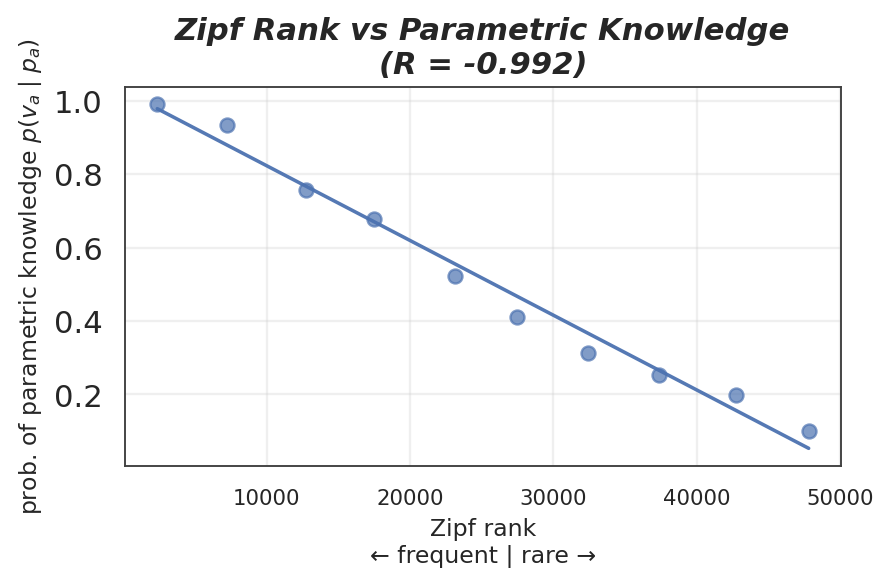

INFO:zipf_prob_relationship:Zipf rank vs prob_param: R = -0.9917, slope = -0.000020


In [2]:
#!/usr/bin/env python3
# ========================================== 
# Zipf rank vs prob_param relationship analysis
# (All attributes combined)
# ========================================== 
import os, re, json, logging, gc, random
from pathlib import Path
from typing import List, Dict, Tuple, Optional
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from transformers import GPT2Tokenizer, GPT2LMHeadModel

# ---------- Logging/Seed ----------
logging.basicConfig(level=logging.INFO)
log = logging.getLogger("zipf_prob_relationship")

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

# ---------- User settings ----------
MODEL_ROOT = Path("./gpt2_runs_0816")
RUN_DIR_NAME_FILTER: Optional[str] = "100_1"
CKPT_STEP_FIXED = 16000
TRAIN_JSON = "../dataset_generation/bioS_train_250806.json"
ATTR_KEYS = ["birth_date", "university"]
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SAMPLE_SIZE = 200
ZIPF_PERM_JSON: Optional[str] = None

# ---------- Style setup ----------
sns.set_theme(
    style="whitegrid",
    rc={
        "figure.dpi": 170,
        "axes.titlesize": 13,
        "axes.labelsize": 10,
        "xtick.labelsize": 9,
        "ytick.labelsize": 13,
        "axes.edgecolor": "0.25",
        "axes.linewidth": 0.8,
    }
)
POINT_ALPHA = 0.7
LINE_ALPHA = 0.95
NUM_BINS = 10

# ---------- Common utilities ----------
def load_json(path: str):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

def list_run_dirs(root: Path, name_filter: Optional[str]):
    runs = []
    for p in root.iterdir():
        if p.is_dir() and (name_filter is None or name_filter in p.name):
            if any(child.is_dir() and child.name.startswith("checkpoint") for child in p.iterdir()):
                runs.append(p)
    runs.sort(key=lambda x: x.name)
    return runs

def list_ckpts_in_range(model_dir: Path, lo: int = 0, hi: int = 10**12):
    cand = []
    for p in model_dir.iterdir():
        if p.is_dir() and p.name.startswith("checkpoint"):
            m = re.findall(r"\d+", p.name)
            if not m:
                continue
            step = int(m[0])
            if lo <= step <= hi:
                cand.append((step, p))
    return [p for step, p in sorted(cand, key=lambda x: x[0])]

def load_zipf_perm_or_identity(n: int, perm_json: Optional[str]) -> List[int]:
    if perm_json is None:
        return list(range(n))
    perm = load_json(perm_json)
    assert isinstance(perm, list) and len(perm) == n
    return perm

def build_idx_to_rank(rank_to_idx: List[int]) -> Dict[int, int]:
    return {idx: rank for rank, idx in enumerate(rank_to_idx)}

def find_ckpt_at_step(root, name_filter, step):
    runs = list_run_dirs(root, name_filter)
    cand = []
    for run_dir in runs:
        c = run_dir / f"checkpoint-{step}"
        if c.is_dir():
            cand.append((c.stat().st_mtime, run_dir.name, c))
        else:
            for p in list_ckpts_in_range(run_dir, step, step):
                cand.append((p.stat().st_mtime, run_dir.name, p))
    if not cand:
        raise FileNotFoundError("checkpoint not found")
    cand.sort(key=lambda x: x[0], reverse=True)
    return cand[0][1], cand[0][2]

@torch.inference_mode()
def full_target_prob(model, tok, prompt_text, full_text):
    max_len = getattr(model.config, "n_ctx", getattr(model.config, "n_positions", 1024))
    ids = tok(full_text, truncation=True, max_length=max_len, return_tensors="pt").input_ids.to(DEVICE)
    logits = model(ids).logits.squeeze(0)
    pl = len(tok(prompt_text)["input_ids"])
    tgt_ids = ids.squeeze(0)[pl:]
    
    prob_product = 1.0
    for i in range(len(tgt_ids)):
        pos = pl + i - 1
        logits_pos = logits[pos]
        probs = F.softmax(logits_pos, dim=-1)
        tid = tgt_ids[i].item()
        p = probs[tid].item()
        prob_product *= max(p, 1e-38)
    
    return float(prob_product)

def bin_xy(x, y, num_bins=10):
    """Bin by x, return x mean and y mean per bin"""
    mask = np.isfinite(x) & np.isfinite(y)
    x_clean = x[mask]
    y_clean = y[mask]
    
    if len(x_clean) < 2:
        return None, None
    
    x_min, x_max = x_clean.min(), x_clean.max()
    if x_min == x_max:
        return None, None
    
    bins = np.linspace(x_min, x_max, num_bins + 1)
    bin_idx = np.digitize(x_clean, bins, right=False) - 1
    bin_idx = np.clip(bin_idx, 0, num_bins - 1)
    
    bin_x_means = []
    bin_y_means = []
    
    for b in range(num_bins):
        mask_b = bin_idx == b
        if not np.any(mask_b):
            continue
        bin_x_means.append(x_clean[mask_b].mean())
        bin_y_means.append(y_clean[mask_b].mean())
    
    if len(bin_x_means) < 2:
        return None, None
    
    return np.array(bin_x_means), np.array(bin_y_means)

# ---------- Main ----------
def run_zipf_prob_analysis():
    log.info("Loading data & tokenizer...")
    tok = GPT2Tokenizer.from_pretrained("gpt2")
    tok.pad_token = tok.eos_token
    
    raw = load_json(TRAIN_JSON)
    
    # If data is in list format
    if isinstance(raw, list):
        o_raw = raw
    elif isinstance(raw, dict) and "orig" in raw:
        o_raw = raw["orig"]
    else:
        o_raw = raw
    
    n_entities = len(o_raw)
    log.info(f"Total entities: {n_entities}")
    
    rank_to_idx = load_zipf_perm_or_identity(n_entities, ZIPF_PERM_JSON)
    idx_to_rank = build_idx_to_rank(rank_to_idx)
    
    all_indices = list(range(n_entities))
    if n_entities > SAMPLE_SIZE:
        sampled_indices = sorted(random.sample(all_indices, SAMPLE_SIZE))
        log.info(f"Sampled {SAMPLE_SIZE} entities")
    else:
        sampled_indices = all_indices
    
    run_name, ckpt_path = find_ckpt_at_step(MODEL_ROOT, RUN_DIR_NAME_FILTER, CKPT_STEP_FIXED)
    log.info(f"Using checkpoint: {run_name} | {ckpt_path}")
    
    model = GPT2LMHeadModel.from_pretrained(ckpt_path).to(DEVICE).eval()
    
    rows = []
    for ent_idx in tqdm(sampled_indices, desc="Computing"):
        o = o_raw[ent_idx]
        zipf_rank = idx_to_rank[ent_idx]
        
        # Compute prob_param for all attributes of each entity
        probs = []
        for attr in ATTR_KEYS:
            if attr not in o.get("probes", {}):
                continue
            prompt_o, tgt_o = o["probes"][attr]
            prompt_text = " " + prompt_o
            full_text = " " + prompt_o + tgt_o
            prob_param = full_target_prob(model, tok, prompt_text, full_text)
            probs.append(prob_param)
        
        # Average prob_param for this entity
        if probs:
            avg_prob = np.mean(probs)
            rows.append({
                "entity_idx": ent_idx,
                "zipf_rank": zipf_rank,
                "prob_param": avg_prob,
            })
    
    del model
    if DEVICE == "cuda":
        torch.cuda.empty_cache()
    gc.collect()
    
    df = pd.DataFrame(rows)
    log.info(f"Total data points: {len(df)}")
    
    # ---- Zipf rank vs prob_param relationship plot ----
    zipf_ranks = df["zipf_rank"].values
    prob_params = df["prob_param"].values
    
    # Binning
    bx, by = bin_xy(zipf_ranks, prob_params, NUM_BINS)
    
    if bx is None:
        log.error("Binning failed")
        return df
    
    # Compute correlation coefficient
    R = np.corrcoef(bx, by)[0, 1]
    
    # Plot
    fig, ax = plt.subplots(figsize=(5.4, 3.6))
    
    color = sns.color_palette("deep")[0]
    ax.scatter(bx, by, s=35, alpha=POINT_ALPHA, color=color)
    
    # Linear trend line
    coef = np.polyfit(bx, by, 1)
    x_line = np.linspace(bx.min(), bx.max(), 100)
    y_line = np.polyval(coef, x_line)
    ax.plot(x_line, y_line, color=color, alpha=LINE_ALPHA)
    
    ax.set_xlabel("Zipf rank\n← frequent | rare →")
    ax.set_ylabel(r"prob. of parametric knowledge $p(v_a \mid p_a)$")
    ax.set_title(f"Zipf Rank vs Parametric Knowledge\n(R = {R:.3f})", 
                fontweight="bold", fontstyle="italic")
    ax.grid(alpha=0.3)
    
    plt.tight_layout()
    fig.savefig(f"zipf_vs_prob_param_combined.png", dpi=300, bbox_inches="tight")
    fig.savefig(f"zipf_vs_prob_param_combined.pdf", bbox_inches="tight")
    plt.show()
    
    log.info(f"Zipf rank vs prob_param: R = {R:.4f}, slope = {coef[0]:.6f}")
    
    return df

# ====== Execution ====== 
if __name__ == "__main__":
    df_result = run_zipf_prob_analysis()